In [ ]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
from numba import njit

In [ ]:
@njit
def Laplace2D_FDM(V_ini, max_iter=1000,  tol=1e-4):
    V = V_ini.copy()
    dif = float('inf')
    k = 0

    while dif > tol and k < max_iter:
        V_old = V.copy()

        # Actualización de Jacobi
        for i in range(1, V.shape[0] - 1):
            for j in range(1, V.shape[1] - 1):
                V[i, j] = 0.25 * (V_old[i+1, j] + V_old[i-1, j] + V_old[i, j+1] + V_old[i, j-1])

        # Cálculo del cambio máximo entre iteraciones
        dif = np.max(np.abs(V - V_old))
        k += 1

    print(f"Convergió en {k} iteraciones con dif = {dif}")
    return V


In [ ]:
@njit

def CAPACITOR(V_ini, max_iter=1000,x1=45 , x2=55 , y1=30 , y2=70 ,  tol=1e-3):
    V = V_ini.copy()
    dif = float('inf')
    k = 0

    while dif > tol and k < max_iter:
        V_old = V.copy()

        # Actualización de Jacobi
        for i in range(1, V.shape[0] - 1):
            for j in range(1, V.shape[1] - 1):
              if (i== x1 or i== x2) and (j>=y1 and j<=y2): continue # Para mantener constantes los potenciales en las placas
              V[i, j] = 0.25 * (V_old[i+1, j] + V_old[i-1, j] + V_old[i, j+1] + V_old[i, j-1])

        # Cálculo del cambio máximo entre iteraciones
        dif = np.max(np.abs(V - V_old))
        k += 1

    print(f"Convergió en {k} iteraciones con dif = {dif}")
    return V

In [ ]:
def un(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100 #Voltage
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] #filed value
  #return grid
  return X,Y,Z

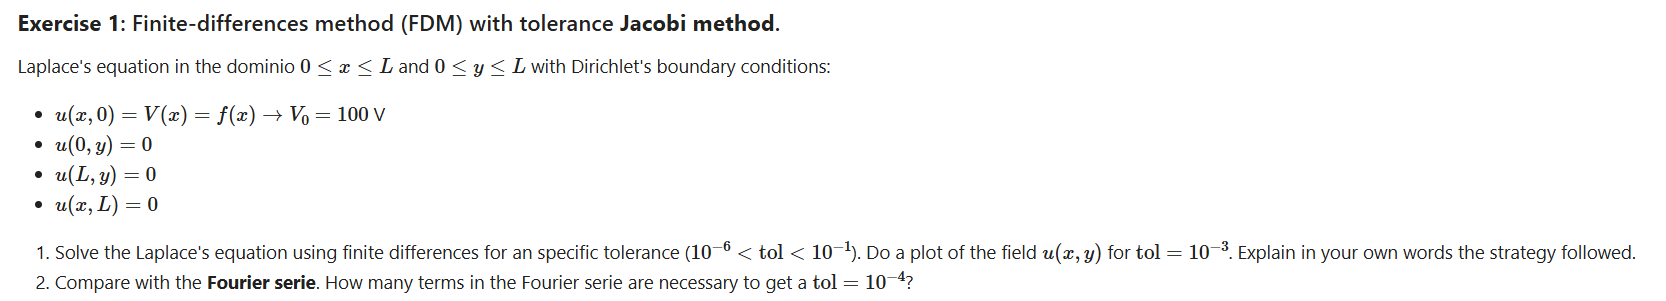

Convergió en 10562 iteraciones con dif = <object type:float64>
time (s)= 0.48807070700001987


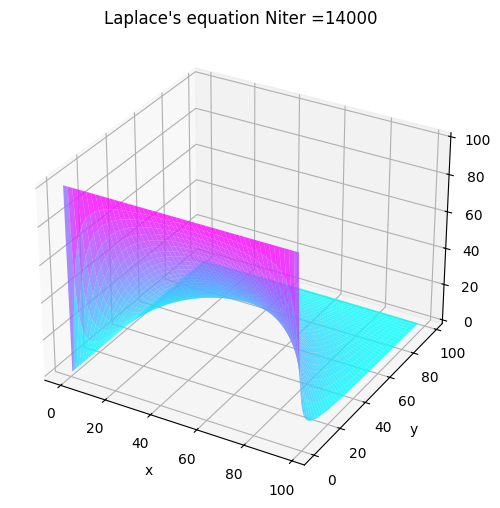

In [ ]:
Nmax, Niter,tole = 100, 4000, 1e-3

# Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100. # inerior a 100 V

# Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x

# propagate signal
start = tm.process_time() # Starting time counter for user
# Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter, tole)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )

# Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'% Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Convergió en 3000 iteraciones con dif = <object type:float64>
time (s)= 0.13587339499997597
Convergió en 5991 iteraciones con dif = <object type:float64>
time (s)= 0.25843308899993644
Convergió en 7000 iteraciones con dif = <object type:float64>
time (s)= 0.3029512569999042
Convergió en 10000 iteraciones con dif = <object type:float64>
time (s)= 0.4441394570000057


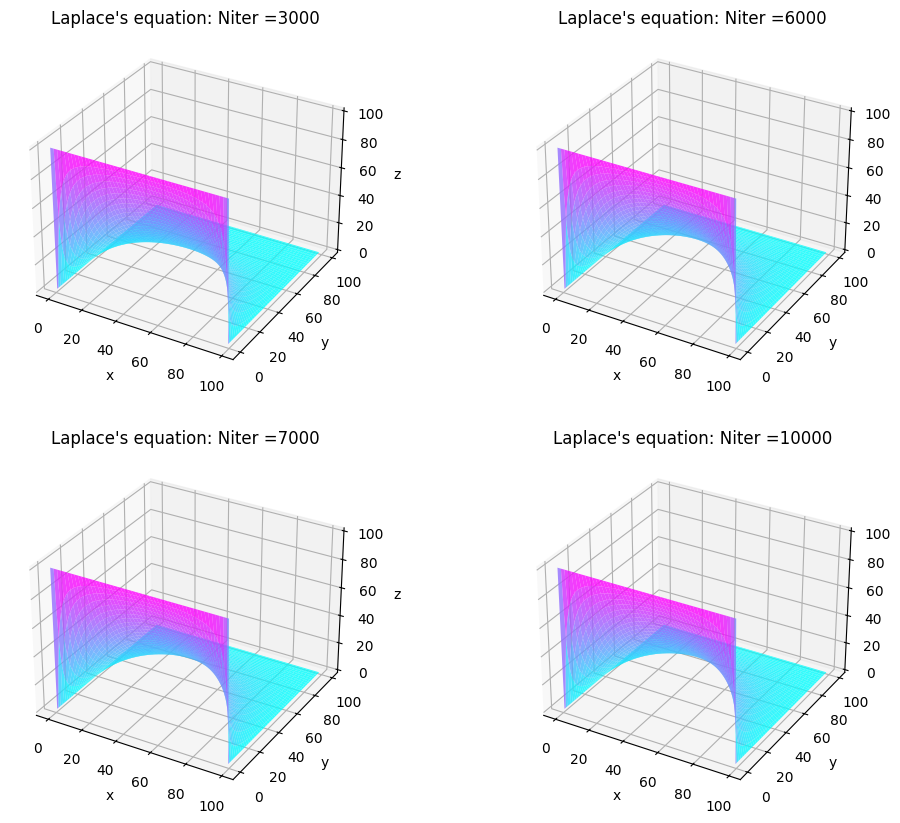

In [ ]:
fig, ax= plt.subplots(2,2, subplot_kw={'projection': '3d'},figsize=(12,10))

# Redefine Nmax and related variables for this cell to ensure consistency
Nmax = 100
# Initial V matrix for Nmax=100
V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100. # boundary condition

# Do the grid to plot - x and y should cover all indices from 0 to Nmax-1
x = np.arange(0, Nmax, 1) # indices 0 to 99
y = np.arange(0, Nmax, 1) # indices 0 to 99


Niter, tole = 3000, 1e-3
#Run Laplace2D rutine
start = tm.process_time()
V = Laplace2D_FDM(V_ini, Niter) # V_ini is (100,100) now
X,Y,Z = grid(V,x,y) # x,y are [0..99], so X,Y values are 0..99
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )
#Plot the field
ax[0,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,0].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
ax[0,0].set_zlabel('z')
#************************************


Niter, tole = 6000, 1e-3
#Run Laplace2D rutine
start = tm.process_time()
V = Laplace2D_FDM(V_ini, Niter, tol=tole)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )
#Plot the field
ax[0,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[0,1].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_zlabel('z')


#************************************
Niter, tole = 7000, 1e-4
#Run Laplace2D rutine
start = tm.process_time()
V = Laplace2D_FDM(V_ini, Niter, tol=tole)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )
#Plot the field
ax[1,0].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,0].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('y')
ax[1,0].set_zlabel('z')

#************************************
Niter, tole = 10000, 1e-4
#Run Laplace2D rutine
start = tm.process_time()
V = Laplace2D_FDM(V_ini, Niter,tol=tole)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )
#Plot the field
ax[1,1].plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax[1,1].set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('y')
ax[1,1].set_zlabel('z')

plt.show()

Haciendo la comparacion de los metodos de diferencias finitas y el metodo de fourier priemro definimos ciertos parametros iguales en ambos para poder comparar: Mallas de 100x100, tolerancia de 1e-4. Con el metodo de fourier necesitamos apenas 101 iteracciones para  llegar a tal nivel de tolerancia, mientras que para el metodo de diferencias finitas se necesitan 10512 iteracciones para llegar a este mismo nivel.

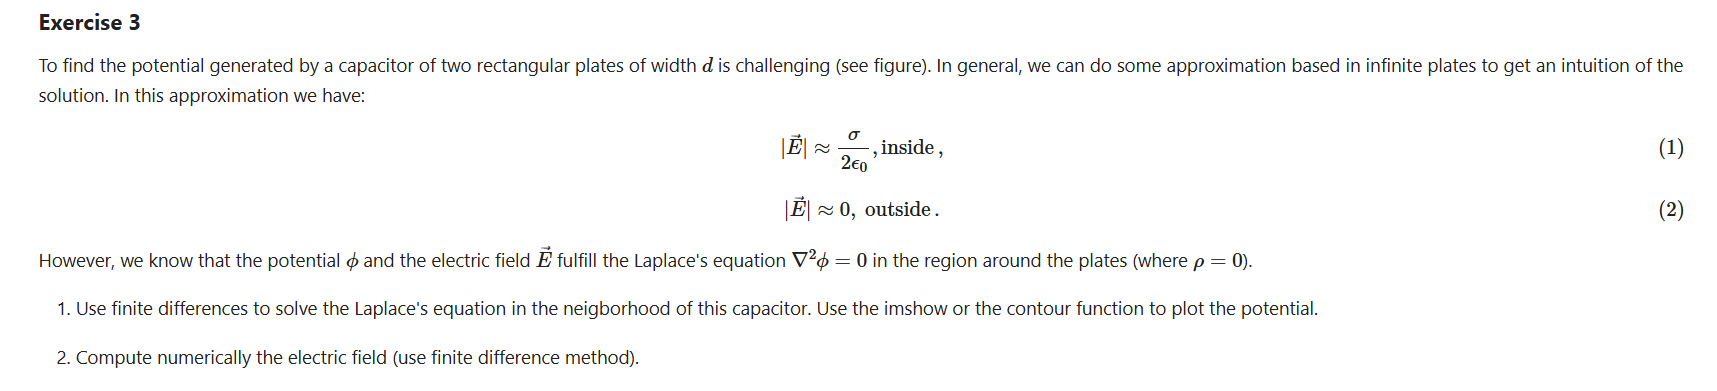

Convergió en 3000 iteraciones con dif = <object type:float64>
time (s)= 0.13461201899997377


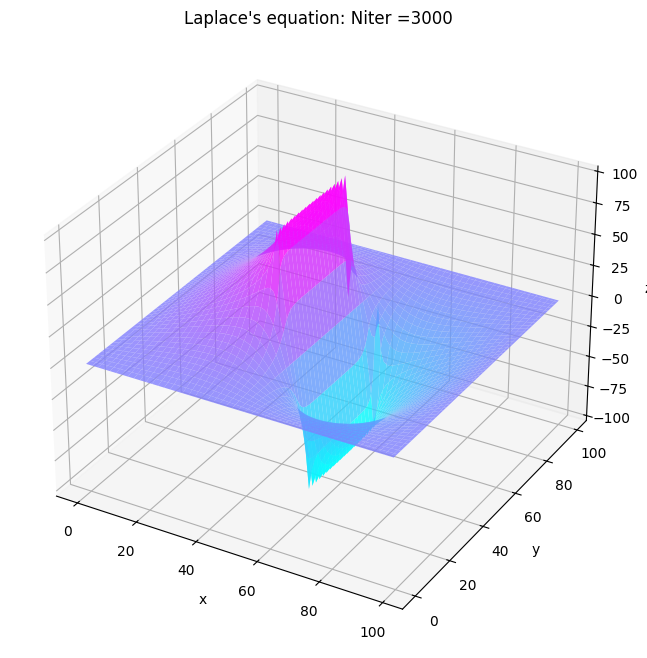

In [ ]:
Nmax, Niter,tole = 100, 3000, 1e-7
y_1= 30
y_2= 70

# Initial V matrix
V_ini2 = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(y_1, y_2):
  V_ini2[45,k] =  100 ##Barra en poscion x=45 que va desde y=30 hasta y=70
  V_ini2[55,k] = -100

#Run Laplace2D rutine
start = tm.process_time()
V = CAPACITOR(V_ini2, Niter, y1= y_1, y2= y_2, tol= tole)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )
#Plot the field
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation: Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

<Figure size 1000x600 with 0 Axes>

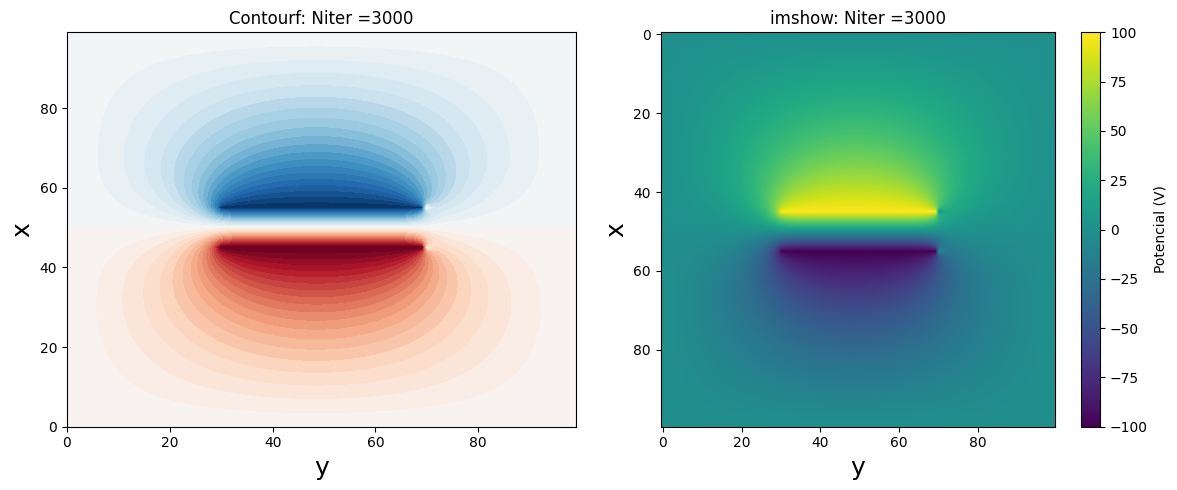

In [ ]:
plt.figure(figsize=(10,6))

# Crear figura
fig = plt.figure(figsize=(12,5))

#  Subplot 1: Superficie 3D
ax1 = fig.add_subplot(1,2,1)
ax1.contourf(V,levels = 40, cmap='RdBu_r')
ax1.set_title('Contourf: Niter =%.1d'%Niter)
ax1.set_xlabel("y",size=18)
ax1.set_ylabel("x",size=18)

# Subplot 2: Campo eléctrico 2D
ax2 = fig.add_subplot(1,2,2)
im = ax2.imshow(V.copy(), interpolation="bilinear", ) # cmap="hot"


ax2.set_title('imshow: Niter =%.1d'%Niter)
ax2.set_xlabel("y",size=18)
ax2.set_ylabel("x",size=18)

# Barra de color (solo una, asociada al potencial)
fig.colorbar(im, ax=ax2, label='Potencial (V)')


plt.tight_layout()
plt.show()

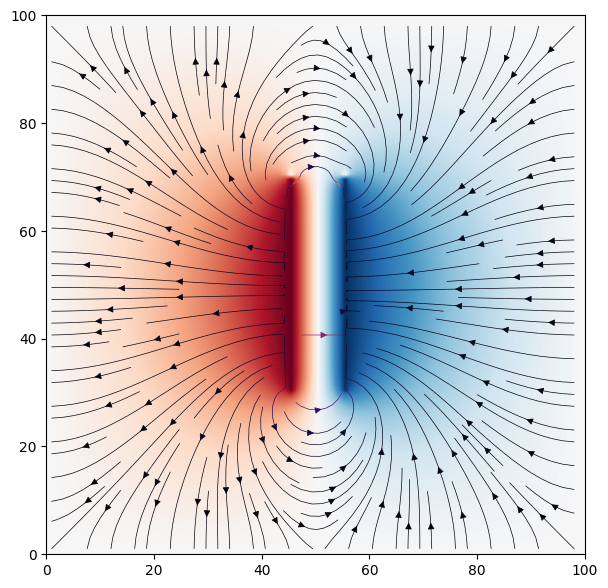

In [ ]:
U = V.copy()

err = 1e-5
d = 10
l = 20
volt = 50
Nx = Nmax
Ny = Nmax
# GRID PARAMETERS
d_grid = d*Nx/100
l_grid = l*Ny/100

# Central derivative for E field
E = -np.stack([
    (U[2:, 1:-1] - U[0:-2, 1:-1]) / 2,
    (U[1:-1, 2:] - U[1:-1, 0:-2]) / 2,
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]
#E[..., 0] es una sintaxis de indexación en NumPy para arrays multidimensionales.

# Interior grid coordinates matching E's shape (Nx-2, Ny-2)
x = np.arange(1, Nx-1)
y = np.arange(1, Ny-1)
X, Y = np.meshgrid(x, y, indexing='ij')

fig, ax = plt.subplots(figsize=(7, 7))

# Background: potential
#ax.imshow(U.T, interpolation="bilinear", extent=[0, Nx, 0, Ny])
ax.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny],interpolation="bilinear")

# Streamlines, colored by field magnitude
magnitude = np.sqrt(Ex**2 + Ey**2)
ax.streamplot(X.T, Y.T, Ex.T, Ey.T,
                color = magnitude.T, cmap = 'inferno',
                density=1.5, linewidth=0.5)

ax.set_aspect('equal')
plt.show()